In [2]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix

Creare baza de imagini

Baza de date creata: 200 imagini de dimensiune (32, 32, 3)
Clase: ['Normal', 'Sepia']


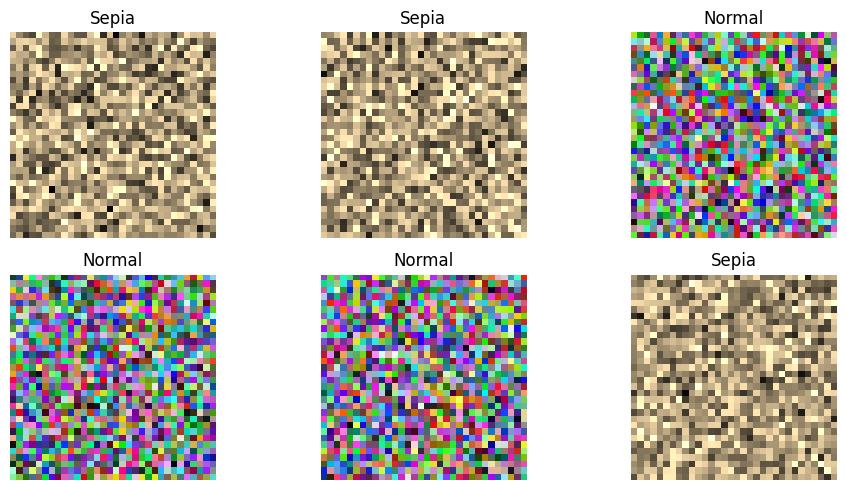

In [9]:
def create_sepia_filter():
    # Returneaza matricea de transformare sepia
    return np.array([
        [0.393, 0.769, 0.189],
        [0.349, 0.686, 0.168],
        [0.272, 0.534, 0.131]
    ])


def apply_sepia(image, sepia_matrix):
    # Aplica filtrul sepia unei imagini
    sepia_img = image @ sepia_matrix.T
    return np.clip(sepia_img, 0, 1)

def show_examples(images, labels, class_names, num_examples=6):
    plt.figure(figsize=(10, 5))

    for i in range(num_examples):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def generate_dataset(num_images=200, img_size=(32, 32, 3), seed=42):
    # Genereaza un set de date cu imagini normale si sepia
    np.random.seed(seed)

    # Generează imagini aleatorii
    images = np.random.rand(num_images, *img_size)

    # Labels: 0 = Normal, 1 = Sepia
    labels = np.zeros(num_images, dtype=int)

    sepia_matrix = create_sepia_filter()

    # Aplica sepia pe a doua jumatate
    for i in range(num_images // 2, num_images):
        images[i] = apply_sepia(images[i], sepia_matrix)
        labels[i] = 1

    # Shuffle dataset
    indices = np.random.permutation(num_images)
    images = images[indices]
    labels = labels[indices]

    return images, labels

images, labels = generate_dataset()

class_names = ['Normal', 'Sepia']

print(f"Baza de date creata: {len(images)} imagini de dimensiune {images[0].shape}")
print(f"Clase: {class_names}")
show_examples(images, labels, class_names)

Forma imaginii: (200, 3072)
Date de antrenare: 160 | Date de test: 40


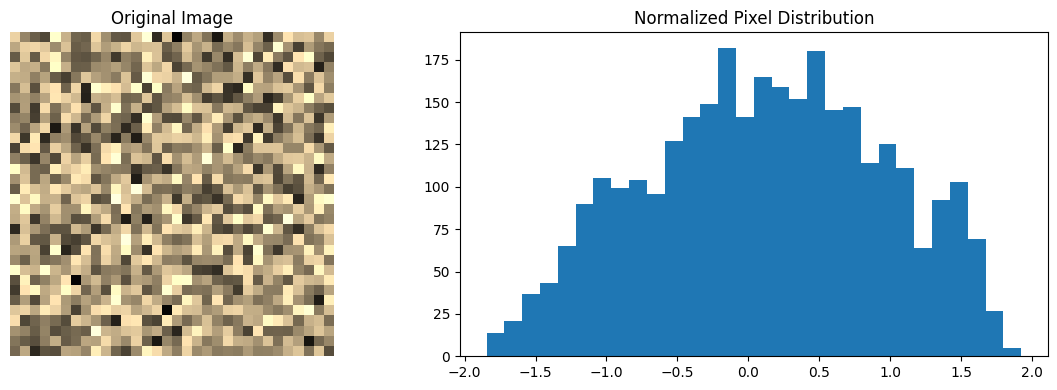

In [26]:
def flatten_images(images):
    return images.reshape(images.shape[0], -1)


def split_data(inputs, outputs, train_ratio=0.8, seed=4):
    np.random.seed(seed)

    indices = np.random.permutation(len(inputs))
    split_idx = int(train_ratio * len(inputs))

    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]

    return (
        inputs[train_idx],
        outputs[train_idx],
        inputs[test_idx],
        outputs[test_idx]
    )


def normalize_data(train_data, test_data):
    scaler = StandardScaler()
    return scaler.fit_transform(train_data), scaler.transform(test_data)


def plot_examples(original_images, flattened_images, normalized_data):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(original_images[0])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.hist(normalized_data[0], bins=30)
    plt.title("Normalized Pixel Distribution")

    plt.tight_layout()
    plt.show()


inputs_flatten = flatten_images(images)

print("Forma imaginii:", inputs_flatten.shape)

trainInputs, trainOutputs, testInputs, testOutputs = split_data(
    inputs_flatten, labels
)

trainInputs, testInputs = normalize_data(trainInputs, testInputs)

print(f"Date de antrenare: {len(trainInputs)} | Date de test: {len(testInputs)}")

plot_examples(images, inputs_flatten, trainInputs)

---------------------------------------------------------------------------------------------------------------------------------------------------------

ANN Tool

In [27]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots()
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]

            color = "green" if i == j else "red"

            ax.add_patch(plt.Rectangle((j, i), 1, 1, color=color, alpha=0.3))
            ax.text(j + 0.5, i + 0.5, str(value),
                    ha="center", va="center", fontsize=12)

    ax.set_xlim(0, cm.shape[1])
    ax.set_ylim(0, cm.shape[0])

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    ax.invert_yaxis()
    plt.show()

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000


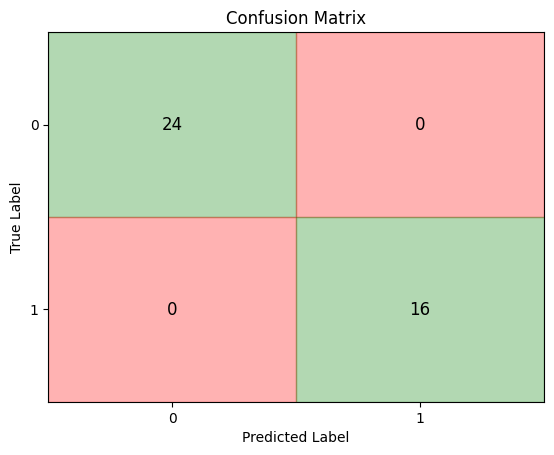

In [28]:
ann_tool = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', max_iter=200, solver='adam', random_state=1, learning_rate_init=0.001)

ann_tool.fit(trainInputs, trainOutputs)
predictedLabels = ann_tool.predict(testInputs)

print(f"Accuracy: {accuracy_score(testOutputs, predictedLabels):.4f}")
print(f"Precision: {precision_score(testOutputs, predictedLabels):.4f}")
print(f"Recall: {recall_score(testOutputs, predictedLabels):.4f}")

plot_confusion_matrix(testOutputs, predictedLabels)

---------------------------------------------------------------------------------------------------------------------------------------------------------

Importanta Hyperparametrilor

In [31]:
def evaluate_configs(configs, X_train, y_train, X_test, y_test):
    print(f"{'Hidden Layers':<20} | {'Learning Rate':<15} | {'Max Iter':<10} | {'Accuracy'}")
    print("-" * 70)

    results = []

    for cfg in configs:
        model = MLPClassifier(
            hidden_layer_sizes=cfg["hidden_layers"],
            learning_rate_init=cfg["lr"],
            max_iter=cfg["max_iter"],
            activation="relu",
            solver="adam",
            random_state=42
        )

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)

        results.append((cfg, acc))

        print(f"{str(cfg['hidden_layers']):<20} | {cfg['lr']:<15} | {cfg['max_iter']:<10} | {acc:.4f}")

    return results


hyperparameter_configs = [
    {"hidden_layers": (3,), "lr": 0.01, "max_iter": 50},

    {"hidden_layers": (50,), "lr": 1.0, "max_iter": 100},

    {"hidden_layers": (10,), "lr": 0.001, "max_iter": 40},

    {"hidden_layers": (200, 100, 50), "lr": 0.001, "max_iter": 50},

    {"hidden_layers": (50, 25), "lr": 0.001, "max_iter": 200},
]


results = evaluate_configs(
    hyperparameter_configs,
    trainInputs, trainOutputs,
    testInputs, testOutputs
)

Hidden Layers        | Learning Rate   | Max Iter   | Accuracy
----------------------------------------------------------------------
(3,)                 | 0.01            | 50         | 1.0000
(50,)                | 1.0             | 100        | 1.0000
(10,)                | 0.001           | 40         | 1.0000
(200, 100, 50)       | 0.001           | 50         | 1.0000
(50, 25)             | 0.001           | 200        | 1.0000


---------------------------------------------------------------------------------------------------------------------------------------------------------

ANN (Cod Propriu)

Acuratete ANN propriu: 1.0000


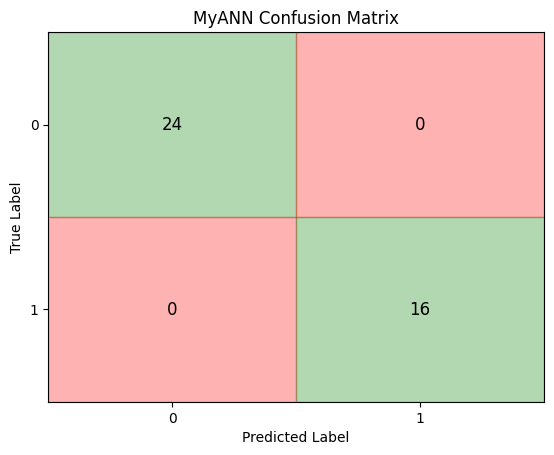

In [32]:
class MyANN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01, epochs=1000, seed=42):
        self.lr = lr
        self.epochs = epochs

        np.random.seed(seed)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, sigmoid_output):
        return sigmoid_output * (1 - sigmoid_output)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.sigmoid(self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)

        return self.A2

    def backward(self, X, y, m):
        dZ2 = self.A2 - y
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

        dZ1 = np.dot(dZ2, self.W2.T) * self.sigmoid_derivative(self.A1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # update
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        m = X.shape[0]

        for epoch in range(self.epochs):
            self.forward(X)
            self.backward(X, y, m)

    def predict(self, X):
        X = np.array(X)
        probs = self.forward(X)
        return (probs >= 0.5).astype(int).flatten()


my_ann = MyANN(
    input_size=len(trainInputs[0]),
    hidden_size=10,
    output_size=1,
    lr=0.01,
    epochs=1000
)

my_ann.fit(trainInputs, trainOutputs)

my_predictions = my_ann.predict(testInputs)

print(f"Acuratete ANN propriu: {accuracy_score(testOutputs, my_predictions):.4f}")
plot_confusion_matrix(testOutputs, my_predictions, title="MyANN Confusion Matrix")

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

CNN ( Cod Propriu )

In [33]:
# ---------- ACTIVATIONS ----------
def relu(x):
    return np.maximum(0, x)

def derivata_relu(x):
    return (x > 0).astype(float)

# ---------- LOSS & SIGMOID ----------
class StratSigmoid:
    def forward(self, x):
        self.out = 1 / (1 + np.exp(-np.clip(x, -500, 500)))
        return self.out
    def backward(self, grad, lr):
        return grad * self.out * (1 - self.out)

def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def derivata_bce(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return (y_pred - y_true) / (y_pred * (1 - y_pred) * y_true.size)

# ---------- LAYERS ----------
class StratDens:
    def __init__(self, intrari, iesiri):
        self.ponderi = np.random.randn(intrari, iesiri) * np.sqrt(2. / intrari)
        self.bias = np.zeros((1, iesiri))

    def forward(self, intrare):
        self.intrare = intrare
        return np.dot(intrare, self.ponderi) + self.bias

    def backward(self, eroare_iesire, lr):
        grad_w = np.dot(self.intrare.T, eroare_iesire)
        grad_b = np.sum(eroare_iesire, axis=0, keepdims=True)
        grad_intrare = np.dot(eroare_iesire, self.ponderi.T)

        self.ponderi -= lr * grad_w
        self.bias -= lr * grad_b
        return grad_intrare

class StratActivareReLU:
    def forward(self, intrare):
        self.intrare = intrare
        return relu(intrare)
    def backward(self, grad, lr):
        return grad * derivata_relu(self.intrare)

class StratFlatten:
    def forward(self, intrare):
        self.shape = intrare.shape
        return intrare.reshape(1, -1)
    def backward(self, grad, lr):
        return grad.reshape(self.shape)

class StratMaxPool:
    def __init__(self, size=2):
        self.size = size

    def forward(self, x):
        self.x = x
        c, h, w = x.shape
        self.out = np.zeros((c, h // self.size, w // self.size))
        for i in range(0, self.out.shape[1]):
            for j in range(0, self.out.shape[2]):
                region = x[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                self.out[:, i, j] = np.max(region, axis=(1, 2))
        return self.out

    def backward(self, grad, lr):
        dx = np.zeros_like(self.x)
        c, h_out, w_out = grad.shape
        for i in range(h_out):
            for j in range(w_out):
                region = self.x[:, i*self.size:(i+1)*self.size, j*self.size:(j+1)*self.size]
                for ch in range(c):
                    # Gasim indexul valorii maxime in fereastra
                    idx = np.argmax(region[ch])
                    ii, jj = np.unravel_index(idx, (self.size, self.size))
                    dx[ch, i*self.size + ii, j*self.size + jj] += grad[ch, i, j]
        return dx

class StratConv2D:
    def __init__(self, in_channels, out_channels, k):
        self.k = k
        self.c_out = out_channels
        self.filtre = np.random.randn(out_channels, in_channels, k, k) * np.sqrt(2. / (in_channels * k * k))
        self.bias = np.zeros((out_channels, 1))

    def forward(self, x):
        self.x = x
        c_in, h, w = x.shape
        h_out, w_out = h - self.k + 1, w - self.k + 1
        self.out = np.zeros((self.c_out, h_out, w_out))

        for i in range(h_out):
            for j in range(w_out):
                region = x[:, i:i+self.k, j:j+self.k]
                # Operatie vectorizata pe toate filtrele simultan
                self.out[:, i, j] = np.sum(region * self.filtre, axis=(1, 2, 3)) + self.bias.flatten()
        return self.out

    def backward(self, grad, lr):
        d_filters = np.zeros_like(self.filtre)
        d_input = np.zeros_like(self.x)
        
        for i in range(grad.shape[1]):
            for j in range(grad.shape[2]):
                region = self.x[:, i:i+self.k, j:j+self.k]
                for f in range(self.c_out):
                    d_filters[f] += grad[f, i, j] * region
                    d_input[:, i:i+self.k, j:j+self.k] += grad[f, i, j] * self.filtre[f]

        self.filtre -= lr * d_filters
        self.bias -= lr * np.sum(grad, axis=(1, 2)).reshape(-1, 1)
        return d_input

# ---------- TRAINING LOOP ----------
def antreneaza(retea, X, Y, epoci=10, lr=0.01):
    for epoca in range(epoci):
        loss_total = 0
        correct = 0

        for x, y in zip(X, Y):
            # Forward
            out = x
            for strat in retea:
                out = strat.forward(out)

            loss_total += binary_cross_entropy(y, out)
            pred = 1 if out[0][0] > 0.5 else 0
            if pred == int(y[0]):
                correct += 1

            # Backward
            grad = derivata_bce(y, out)
            for strat in reversed(retea):
                grad = strat.backward(grad, lr)

        print(f"Epoca {epoca+1}/{epoci} | Loss: {loss_total/len(X):.4f} | Acc: {100*correct/len(X):.1f}%")

In [35]:
# Transpunem imaginile pentru formatul (C, H, W) cerut de CNN
images_cnn = images.transpose(0, 3, 1, 2) 

# Split pe datele brute (fara flatten)
indices = np.random.permutation(len(images_cnn))
split_idx = int(0.8 * len(images_cnn))

train_X = images_cnn[indices[:split_idx]]
train_Y = labels[indices[:split_idx]].reshape(-1, 1)
test_X = images_cnn[indices[split_idx:]]
test_Y = labels[indices[split_idx:]].reshape(-1, 1)

# Definire arhitectura
model = [
    StratConv2D(3, 4, k=3),
    StratActivareReLU(),
    StratMaxPool(2), 
    StratFlatten(),
    StratDens(900, 1),
    StratSigmoid()
]

# Antrenare
antreneaza(model, train_X, train_Y, epoci=5, lr=0.01)

Epoca 1/5 | Loss: 0.6952 | Acc: 58.8%
Epoca 2/5 | Loss: 0.2430 | Acc: 94.4%
Epoca 3/5 | Loss: 0.0182 | Acc: 100.0%
Epoca 4/5 | Loss: 0.0075 | Acc: 100.0%
Epoca 5/5 | Loss: 0.0046 | Acc: 100.0%


In [51]:
def test(retea, X_test, Y_test):
    correct = 0
    predicted = []
    
    for x, y in zip(X_test, Y_test):
        out = x
        for strat in retea:
            out = strat.forward(out)
        
        pred = 1 if out[0][0] > 0.5 else 0
        predicted.append(pred)
        
        if pred == int(y[0]):
            correct += 1
            
    accuracy = 100 * correct / len(X_test)
    print(f"Acuratete CNN propriu: {accuracy:.2f}%")
    return predicted

preds = test(model, test_X, test_Y)

Acuratete CNN propriu: 100.00%
